# Oxygen Tension and Metabolic Adaptation

### Goal
Examine how metabolic reprogramming (OXPHOS vs Glycolysis) correlates with the oxygen tension of the target metastatic tissue.

### Purpose
To determine if the local metastatic microenvironment (e.g., highly oxygenated liver vs hypoxic environments) dictates the specific metabolic pathway reliance of the metastasizing tumor cells.

### Interpretation
- **OXPHOS/Glycolysis Ratio:** A ratio > 1 indicates a preference for Oxidative Phosphorylation. \n- **Tissue Correlation:** Liver metastases typically show higher OXPHOS reliance compared to more hypoxic sites like chest wall.

### Data Provenance: KEGG Pathway Definition

To ensure strict scientific reproducibility, the gene signatures for **Glycolysis** (hsa00010), **Oxidative Phosphorylation** (hsa00190), and **HIF-1 Signaling** (hsa04066) are programmatically fetched from the KEGG REST API rather than being hardcoded.

The extraction script (`scripts/fetch_kegg_pathways.py`) retrieves the HGNC symbols corresponding to each KEGG pathway to precisely define our analytical signatures.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sys
import os

# Ensure the scripts directory is in path to import our modular scripts
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.append(os.path.abspath(os.getcwd()))

from scripts.compute_metabolic_switching import compute_enrichment_ratios

sns.set_theme(style="whitegrid")

import sys
if '..' not in sys.path: sys.path.append('..')
from pan_cancer_config import ANALYSIS_SUFFIX

### 1. Compute Enrichment Ratios
We compute the OXPHOS / Glycolysis Enrichment ratio using the Log2 Fold Change of genes differentially expressed in the Metastasis vs Primary site.

In [ ]:
df_res = compute_enrichment_ratios()
display(df_res)

,Cancer,Mean_Glycolysis_LFC,Mean_OXPHOS_LFC,Mean_HIF1_LFC,OXPHOS_Glycolysis_Ratio,O2_Tension_Tumour_Pct,O2_Tension_Normal_Pct,PMID_Reference,Glycolysis_Genes_Found,OXPHOS_Genes_Found,HIF1_Genes_Found
0,Kidney,-3.123310,-0.497184,-1.825401,6.173658,1.3,4.9,32,49,85,36
1,Breast,1.117735,-0.943899,0.655593,0.239545,1.3,6.8,"5,19",49,85,36
2,Colorectal,-0.434732,-0.620945,-0.547471,0.878910,4.2,6.8,"21,22",49,85,36
3,Ovarian,0.044343,0.307417,0.051291,1.200033,1.2,6.0,5,49,85,36
4,Lung,-1.767947,-0.380673,-0.868325,2.615839,1.9,5.6,17,49,85,36
5,Melanoma,-1.520227,-0.374689,-1.464109,2.212286,1.5,5.3,31,49,85,36


### 2. Visualize Correlation
Plotting the generic O2 tension (%) of the dominant metastatic site for each cancer against the OXPHOS/Glycolysis ratio. A ratio > 1 indicates OXPHOS dominance, while < 1 indicates Glycolysis dominance.

Saved plot to /Users/sakuramaezono/Library/CloudStorage/OneDrive-YokohamaCityUniversity/Personal/05_Python_repositories/metabConnectomeDB/output/oxygen_tension/oxygen_tension_correlation_6MetCan_500k.png
Saved plot to /Users/sakuramaezono/Library/CloudStorage/OneDrive-YokohamaCityUniversity/Personal/05_Python_repositories/metabConnectomeDB/output/oxygen_tension/oxygen_tension_hif1_correlation_6MetCan_500k.png


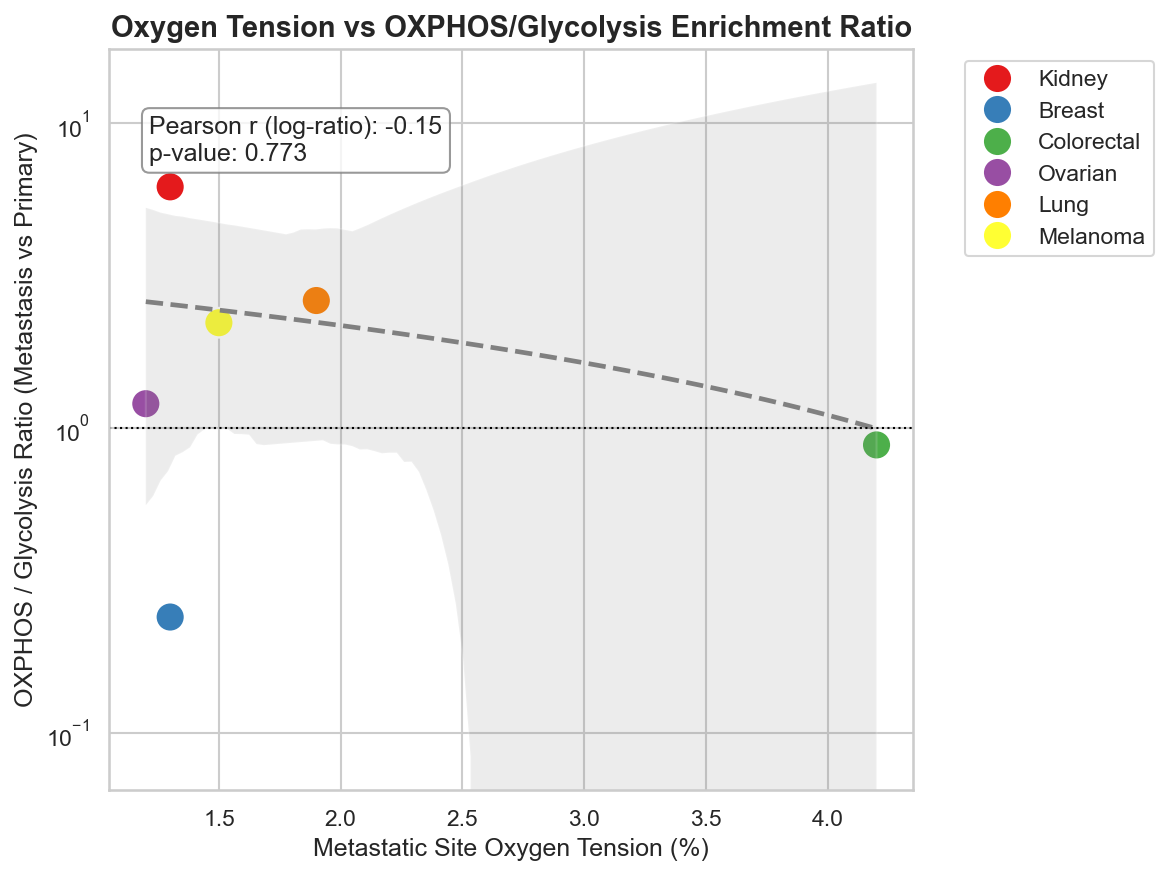

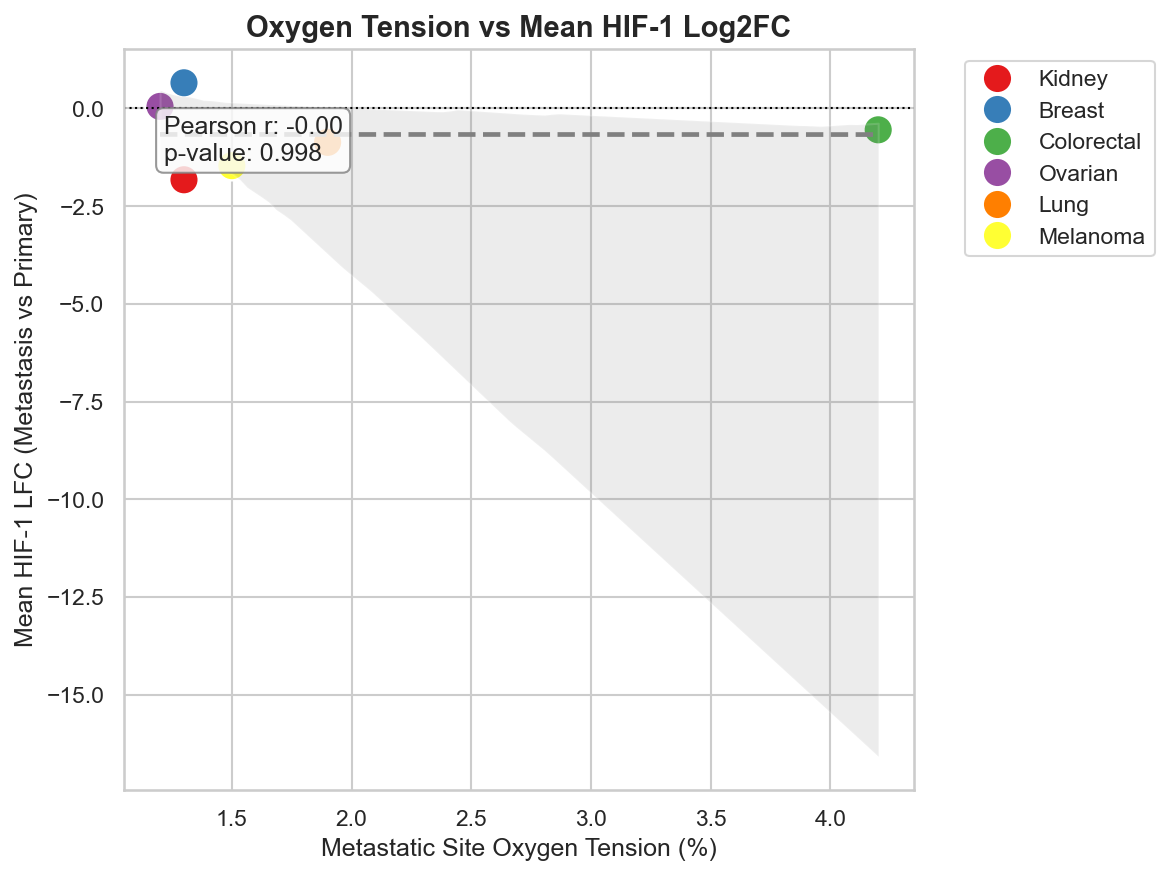

In [ ]:
plt.figure(figsize=(8, 6))

# Clean NaN if any
df_plot = df_res.dropna(subset=['O2_Tension_Tumour_Pct', 'OXPHOS_Glycolysis_Ratio']).copy()

# Scatter plot
sns.scatterplot(
    data=df_plot,
    x='O2_Tension_Tumour_Pct',
    y='OXPHOS_Glycolysis_Ratio',
    hue='Cancer',
    s=200,
    palette='Set1'
)

# Fit line
sns.regplot(
    data=df_plot,
    x='O2_Tension_Tumour_Pct',
    y='OXPHOS_Glycolysis_Ratio',
    scatter=False,
    color='grey',
    line_kws={"linestyle":"--"}
)

plt.title("Oxygen Tension vs OXPHOS/Glycolysis Enrichment Ratio", fontsize=14, weight='bold')
plt.xlabel("Metastatic Site Oxygen Tension (%)", fontsize=12)
plt.ylabel("OXPHOS / Glycolysis Ratio (Metastasis vs Primary)", fontsize=12)
plt.yscale("log") # log scale is better for ratio
plt.axhline(1.0, color='black', linewidth=1, linestyle=':')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Calculate stats
r, p = stats.pearsonr(df_plot['O2_Tension_Tumour_Pct'], np.log2(df_plot['OXPHOS_Glycolysis_Ratio']))
plt.annotate(f"Pearson r (log-ratio): {r:.2f}\np-value: {p:.3f}", 
             xy=(0.05, 0.85), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()

# output path
out_dir = os.path.join(os.path.abspath(os.path.join(os.getcwd(), '..')), "output", "oxygen_tension")
os.makedirs(out_dir, exist_ok=True)
filename = "oxygen_tension_correlation"+ ANALYSIS_SUFFIX + ".png"
output_plot = os.path.join(out_dir,filename)
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
print(f"Saved plot to {output_plot}")
plt.show()

plt.figure(figsize=(8, 6))

# Clean NaN if any
df_plot_hif1 = df_res.dropna(subset=['O2_Tension_Tumour_Pct', 'Mean_HIF1_LFC']).copy()

# Scatter plot
sns.scatterplot(
    data=df_plot_hif1,
    x='O2_Tension_Tumour_Pct',
    y='Mean_HIF1_LFC',
    hue='Cancer',
    s=200,
    palette='Set1'
)

# Fit line
sns.regplot(
    data=df_plot_hif1,
    x='O2_Tension_Tumour_Pct',
    y='Mean_HIF1_LFC',
    scatter=False,
    color='grey',
    line_kws={"linestyle":"--"}
)

plt.title("Oxygen Tension vs Mean HIF-1 Log2FC", fontsize=14, weight='bold')
plt.xlabel("Metastatic Site Oxygen Tension (%)", fontsize=12)
plt.ylabel("Mean HIF-1 LFC (Metastasis vs Primary)", fontsize=12)
plt.axhline(0.0, color='black', linewidth=1, linestyle=':')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Calculate stats
r_hif1, p_hif1 = stats.pearsonr(df_plot_hif1['O2_Tension_Tumour_Pct'], df_plot_hif1['Mean_HIF1_LFC'])
plt.annotate(f"Pearson r: {r_hif1:.2f}\np-value: {p_hif1:.3f}", 
             xy=(0.05, 0.85), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()

# output path
out_dir = os.path.join(os.path.abspath(os.path.join(os.getcwd(), '..')), "output", "oxygen_tension")
os.makedirs(out_dir, exist_ok=True)
filename_hif1 = "oxygen_tension_hif1_correlation"+ ANALYSIS_SUFFIX + ".png"
output_plot_hif1 = os.path.join(out_dir, filename_hif1)
plt.savefig(output_plot_hif1, dpi=300, bbox_inches='tight')
print(f"Saved plot to {output_plot_hif1}")
plt.show()


### 3. Save Notebook as HTML
Ensure styled HTML output is generated for trackability.

In [ ]:
import subprocess
import sys
import os

notebook_filename = 'oxygen_tension_analysis.ipynb'
output_base = 'oxygen_tension_analysis' + ANALYSIS_SUFFIX
output_dir = os.path.join('..', 'output', 'oxygen_tension')
os.makedirs(output_dir, exist_ok=True)

jupyter_bin = os.path.join(os.path.dirname(sys.executable), 'jupyter')
if not os.path.exists(jupyter_bin): jupyter_bin = 'jupyter'

cmd_html = [jupyter_bin, "nbconvert", "--to", "html", notebook_filename, "--output-dir", output_dir, "--output", output_base]
res_html = subprocess.run(cmd_html, capture_output=True, text=True)

if res_html.returncode == 0:
    print(f"🎉 SUCCESS: Notebook successfully exported to '{os.path.join(output_dir, output_base)}.html'")
else:
    print("❌ HTML export failed.")
    print(res_html.stderr)
